In [ ]:
# !pip install --upgrade --force-reinstall numpy==1.25.2
# !pip install --upgrade --force-reinstall gensim==4.3.2

# PADL coursework

In [5]:
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#from gensim.models import Word2Vec

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import random_split

from skimage.metrics import structural_similarity as ssim

PROJECT_DIRECTORY = '/content/drive/MyDrive/padl_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "models/"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q11-train.csv'), delimiter=',', skiprows=1)
# Load header to get feature names
header = np.genfromtxt(DATA_DIRECTORY + '/PADL-Q11-train.csv', delimiter=',', max_rows=1, dtype=str)

# Split data into features and targets and feature names
X = data[:, :-1]
y = data[:, -1]
feature_names = header[:-1]

# Split the available data into training and validation we can be used to debug
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Create model
model_1a = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())
])

# Train model on training data
model_1a.fit(X_train, y_train)

y_val_pred = model_1a.predict(X_val)
print("R²:", r2_score(y_val, y_val_pred))

# Get coefficients
poly_feat_names = model_1a.named_steps['poly'].get_feature_names_out(input_features=feature_names)
coefs = np.hstack((model_1a.named_steps['reg'].intercept_, model_1a.named_steps['reg'].coef_))

print("\nCoefficients:")
print(f"{'Feature':>15s} | {'Coefficient':>12s}")
print("-" * 30)
print(f"{'(intercept)':>15s} | {coefs[0]:>12.6f}")
for name, coef in zip(poly_feat_names, coefs[1:]):
    print(f"{name:>15s} | {coef:>12.6f}")

R²: 1.0

Coefficients:
        Feature |  Coefficient
------------------------------
    (intercept) |     0.072330
              1 |     0.000000
             X1 |     0.401186
             X2 |     0.754930
             X3 |     0.002344
             X4 |     0.438232
             X5 |     0.220535
           X1^2 |    -0.412264
          X1 X2 |     1.843934
          X1 X3 |     2.304733
          X1 X4 |    -0.882282
          X1 X5 |     0.479897
           X2^2 |    -2.013118
          X2 X3 |    -5.068353
          X2 X4 |     1.971427
          X2 X5 |    -1.117802
           X3^2 |    -3.183305
          X3 X4 |     2.464700
          X3 X5 |    -1.380687
           X4^2 |    -0.472026
          X4 X5 |     0.514272
           X5^2 |    -0.129456


/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [ ]:
# Testing X_val_poly should be replaced with the unseen data
unseen = np.loadtxt("PADL-Q11-unseen.csv", delimiter=',', skiprows=1)
unseen_X = unseen[:, :-1]
unseen_y = unseen[:, -1]

y_pred = model_1a.predict(unseen_X)

print("R²:", r2_score(unseen_y, y_pred))


### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q12-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print('Generic Linear Regression')
print(f"Coefficients: {lr_model.coef_}\nSum |coefficients|: {np.sum(np.abs(lr_model.coef_))}")
print(f"R²: {r2_lr:.4f}")

# Now with regularised models
# Define paramter space
alphas = np.logspace(-4, 2, 1000)
r2_threshold = 0.9 * r2_lr

# Initialise optimiation values
best_model = None
best_model_type = ''
best_alpha = None
best_r2 = -np.inf
lowest_coef_sum = np.inf

for alpha in alphas:
    # test L1 and L2 regression
    for model_type, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
        model = model_class(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)

        if r2 >= r2_threshold:
            coef_sum = np.sum(np.abs(model.coef_))
            if coef_sum < lowest_coef_sum:
                best_model = model
                best_model_type = model_type
                best_alpha = alpha
                best_r2 = r2
                lowest_coef_sum = coef_sum

print()
print('Regularised Model')
print(f"Model type: {best_model_type}")
print(f"Alpha: {best_alpha}")
print("Coefficients:", best_model.coef_)
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")
print(f"R²: {best_r2:.4f}")


Generic Linear Regression
Coefficients: [0.05794158 2.89256046 1.06861746 0.10373734]
Sum |coefficients|: 4.122856833996828
R²: 0.9569

Regularised Model
Model type: Lasso
Alpha: 20.66880249629082
Coefficients: [0.06037748 0.36890597 0.95843089 0.        ]
Sum |coefficients|: 1.3877
R²: 0.8614


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q12-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the best regularised model
y_unseen_pred = best_model.predict(X_unseen)

# Evaluate R² on unseen data
r2_unseen = r2_score(y_unseen, y_unseen_pred)
print(f"R² on unseen data: {r2_unseen:.4f}")

### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q13-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Use RFE for feature selection
rfe = RFE(lr_model, n_features_to_select=4)  # Select top 4 features (eliminate least useful feature)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_val_rfe = rfe.transform(X_val)

# Train model on selected features
lr_model_rfe = LinearRegression()
lr_model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = lr_model_rfe.predict(X_val_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with feature selection (RFE): {r2_rfe:.4f}")


R² without preprocessing: 0.9597
R² with feature selection (RFE): 0.9584


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q13-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the baseline model
y_unseen_pred_baseline = lr_model.predict(X_unseen)
y_unseen_pred_rfe = lr_model_rfe.predict(rfe.transform(X_unseen))

r2_unseen_baseline = r2_score(y_unseen, y_unseen_pred_baseline)
r2_unseen_rfe = r2_score(y_unseen, y_unseen_pred_rfe)

# Baseline
print(f"Baseline R² (all features): {r2_unseen_baseline:.4f}")
print(f"R² with RFE-selected features: {r2_unseen_rfe:.4f}")

## Q2

### A

<ipython-input-51-022c7c6c8f89>:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', num_clusters)


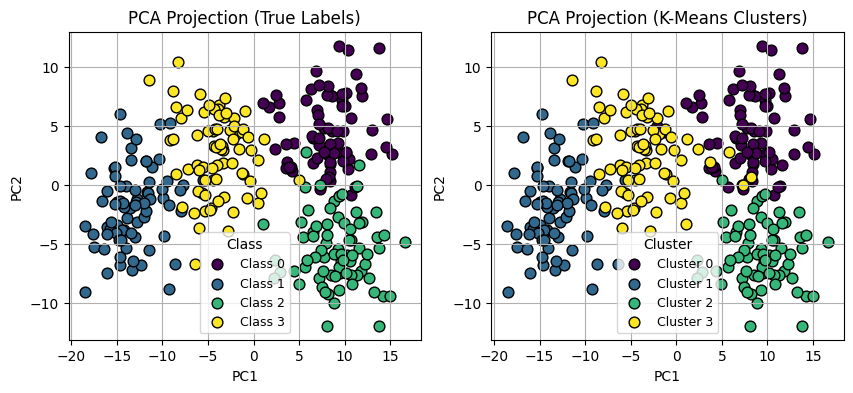

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt((DATA_DIRECTORY + 'PADL-Q2.csv'), delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Colour map
cmap = plt.cm.get_cmap('viridis', num_clusters)

# Create figure
plt.figure(figsize=(10,4))

# Plot 1: PCA with true labels
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(Y)):
    color = cmap(i)
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1],
                label=f'Class {int(label)}', c=[color], edgecolor='k', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (True Labels)')
plt.legend(title='Class', fontsize=9)
plt.grid(True)

# Plot 2: PCA with K-means clusters
plt.subplot(1, 2, 2)
for i in range(num_clusters):
    color = cmap(i)
    plt.scatter(X_pca[Y_kmeans == i, 0], X_pca[Y_kmeans == i, 1],
                label=f'Cluster {i}', c=[color], edgecolor='k', s=60, marker='o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (K-Means Clusters)')
plt.legend(title='Cluster', fontsize=9)
plt.grid(True)

### B

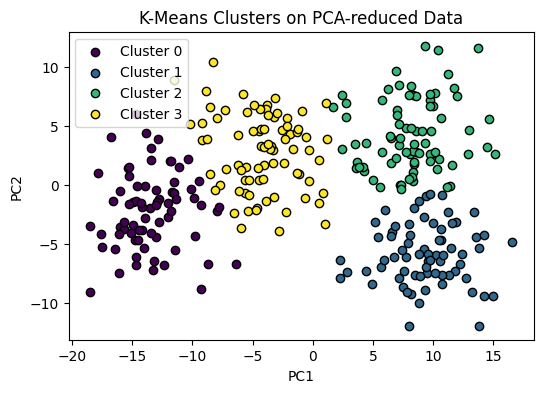

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1],
                label=f"Cluster {cluster}",c=[cmap(cluster)], edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

In [ ]:
def clustering_accuracy(y_true, y_pred):
    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(-cm)
    # Map predicted labels to best-matching true labels
    optimal_mapping = {old: new for old, new in zip(col_ind, row_ind)}
    mapped_preds = np.vectorize(optimal_mapping.get)(y_pred)
    # Return accuracy
    return accuracy_score(y_true, mapped_preds)

acc_full = clustering_accuracy(Y, Y_kmeans)
acc_pca = clustering_accuracy(Y, Y_kmeans_pca)
pca_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Accuracy with all five features: {acc_full:.4f}")
print(f"Accuracy with PCA-reduced features: {acc_pca:.4f}")
print(f"Percentage of variance explained by PCA: {pca_variance:.2f}%")
print(f"Accuracy drop: {acc_full - acc_pca:.2%}")

Accuracy with all five features: 0.9533
Accuracy with PCA-reduced features: 0.9467
Percentage of variance explained by PCA: 77.43%
Accuracy drop: 0.67%


## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open('datasets/PADL-Q3.txt', 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
skip_gram_model = Word2Vec(sentences=sentences, sg=1)
word_embeddings = skip_gram_model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.1919
Node 5 <-> Node 22: 0.1497
Node 5 <-> Node 23: 0.2954
Node 5 <-> Node 24: 0.3021
Node 5 <-> Node 25: 0.2017
Node 5 <-> Node 26: 0.1908
Node 5 <-> Node 27: 0.2411
Node 5 <-> Node 28: 0.2294
Node 5 <-> Node 29: 0.1964
Node 5 <-> Node 30: 0.1898


### B

## Q4

### A

### B

In [52]:
# Get data from body_measurements.csv
data = np.genfromtxt((DATA_DIRECTORY + 'body_measurements.csv'), delimiter=',', skip_header=1, filling_values=np.nan)

# Filter out nan values
valid_rows = ~np.isnan(data).any(axis=1)
data_clean = data[valid_rows]

# Split data into features and labels
X = data_clean[:, :-1]
y = data_clean[:, -1]

# Split into train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

## Look at removing features that arent important

# Preprocesing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# Model
class WaistPredictor(nn.Module):
    def __init__(self, input_size):
        super(WaistPredictor, self).__init__()

        # Feature-wise attention
        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.model = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output layer
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # Apply attention mask to input features
        attn_weights = self.attention(x)  # (batch_size, input_size)
        x = x * attn_weights  # Feature-wise scaling
        return self.model(x)

class ResidualBlock(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        return x + self.block(x)

class WaistPredictor2(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.res_block = ResidualBlock(64)

        self.output_layer = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x * self.attention(x)
        x = self.input_layer(x)
        x = self.res_block(x)
        x = self.output_layer(x)
        return x

# Define model and training parameters
waist_predictor = WaistPredictor2(input_size=X_train_tensor.shape[1])
MAE_loss = nn.L1Loss()
Smooth_loss = nn.SmoothL1Loss()
optimiser = optim.AdamW(waist_predictor.parameters(), lr = 2e-4, weight_decay=3e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimiser, T_0=200, T_mult=2)

epochs = 1000
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)



In [53]:
# Get rid of these
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    total_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = MAE_loss(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    with torch.no_grad():
        val_preds = waist_predictor(X_val_tensor)
        val_loss = MAE_loss(val_preds, y_val_tensor).item()
        val_mae = mean_absolute_error(y_val, val_preds.numpy())  # Real-world MAE

    val_losses.append(val_loss)
    # scheduler.step(val_loss)

    if (epoch+1)%100 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {loss:.2f}, Val MAE: {val_loss:.2f}")

# Switch to evaluation mode
waist_predictor.eval()
with torch.no_grad():
    # Get predictions on the scaled validation data
    y_val_pred = waist_predictor(X_val_tensor).detach().numpy()

# Calculate the MAE in the original scale using sklearn's mean_absolute_error
final_mae = mean_absolute_error(y_val, y_val_pred)
print(f"Final MAE on the validation set: {final_mae:.2f}")

# Plot training and validation loss from epoch 100 to 1000
start_epoch = 100
end_epoch = 1000

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch, end_epoch + 1), train_losses[start_epoch - 1:end_epoch], label="Train Loss", color='blue')
plt.plot(range(start_epoch, end_epoch + 1), val_losses[start_epoch - 1:end_epoch], label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True)
plt.show()


Epoch 100, Train MAE: 46.52, Val MAE: 37.03
Epoch 200, Train MAE: 41.90, Val MAE: 35.01
Epoch 300, Train MAE: 27.00, Val MAE: 34.68
Epoch 400, Train MAE: 31.22, Val MAE: 34.57
Epoch 500, Train MAE: 42.69, Val MAE: 34.30
Epoch 600, Train MAE: 43.62, Val MAE: 34.32
Epoch 700, Train MAE: 37.17, Val MAE: 34.00


KeyboardInterrupt: 

## Q5

### A

### B

In [ ]:
dataset_path = DATA_DIRECTORY + 'garment_images'
labels_csv = DATA_DIRECTORY + 'garment_images/train_labels.csv'

class GarmentImageDataset(Dataset):
    def __init__(self, root_dir, labels_csv, transform=None):
        self.root_dir = root_dir
        self.labels_df = pd.read_csv(labels_csv)
        self.transform = transform
        self.image_paths = []  # Store paths of all images
        self.labels = []  # Store corresponding labels

        for folder_name in os.listdir(root_dir):  # Iterate through folders (0, 1, 2)
            folder_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(folder_path):
                label = int(folder_name)  # Get label from folder name
                for filename in os.listdir(folder_path):
                    if filename.endswith(".jpg"):
                        image_path = os.path.join(folder_path, filename)
                        self.image_paths.append(image_path)
                        self.labels.append(label)

        self.transform = transforms.Compose([
            transforms.ToTensor(), r

        ])
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')  # Open image and ensure RGB format
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 16 * 16, 256),  # Assuming 64x64 input
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Hyperparameters
learning_rate = 1e-4
epochs = 10
batch_size = 128

# Device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Instantiate model, loss function, and optimizer
fashion_classifier = FashionClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fashion_classifier.parameters(), lr=learning_rate)

dataset = GarmentImageDataset(dataset_path, labels_csv)
# Define train/test split sizes
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
fashion_classifier.train()
correct, total = 0, 0
for epoch in range(epochs):
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        print("|",end='')
        optimizer.zero_grad()
        outputs = fashion_classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total += labels.size(0)
        _, predicted = torch.max(outputs, 1)  # Get predicted class indices
        correct += (predicted == labels).sum().item()
    print()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Testing
fashion_classifier.eval()  # Set model to evaluation mode
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dataloader:  # Use the same dataloader for testing
        images, labels = images.to(device), labels.to(device)
        outputs = fashion_classifier(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on the test set: {100 * correct / total:.2f}%")

cpu
|||||||||||||||||
Epoch [1/10], Loss: 0.9650
|||||||||||||||||
Epoch [2/10], Loss: 0.7888
|||||||||||||||||
Epoch [3/10], Loss: 0.5332
|||||||||||||||||
Epoch [4/10], Loss: 0.5034
|||||||||||||||||
Epoch [5/10], Loss: 0.2719
|||||||||||||||||
Epoch [6/10], Loss: 0.2719
|||||||||||||||||
Epoch [7/10], Loss: 0.2876
|||||||||||||||||
Epoch [8/10], Loss: 0.2038
|||||||||||||||||
Epoch [9/10], Loss: 0.3088
|||||||||||||||||
Epoch [10/10], Loss: 0.1514
Accuracy on the test set: 91.83%


In [ ]:
torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier_temp.pth")

In [ ]:
file_size = os.path.getsize(MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

Model size: 8416896 bytes
Model size: 8.0269775390625 MB


## Q6

### A

### B

### C

#### Encoder and Decoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 192x160 → 96x80
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 96x80 → 48x40
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 48x40 → 24x20
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 24x20 → 12x10
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 12 * 10, 32)

    def forward(self, x):
        x = self.convolutions(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 256 * 12 * 10)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 12x10 → 24x20
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 24x20 → 48x40
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 48x40 → 96x80
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 96x80 → 192x160
            nn.Sigmoid(),  # Match input range (0, 1)
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 12, 10)
        return self.deconv(x)

class FaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),  # Convert to tensor
            transforms.Normalize((0.5,), (0.5,))  # Normalize to range [-1, 1]
        ])
        self.image_paths = [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image

dataset_path = DATA_DIRECTORY + "/face_images"
learning_rate = 1e-3
batch_size = 64
epochs = 20

encoder = Encoder()
decoder = Decoder()

train_dataset = FaceDataset(data_dir=dataset_path)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = FaceDataset(data_dir=dataset_path)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)

# Loss function (MSE loss)
def mse_loss(output, target):
    return F.mse_loss(output, target)

# SSIM loss function (in PyTorch)
def ssim_loss(output, target):
    # Convert the images to NumPy arrays and remove the batch dimension
    output = output.squeeze().cpu().detach().numpy()
    target = target.squeeze().cpu().detach().numpy()

    # Compute SSIM and specify the data_range (assuming images are normalized to [-1, 1])
    return 1 - ssim(output, target, data_range=2)

def plot_images(original, reconstructed):
    # Ensure the image is in the correct range [0, 1]
    reconstructed = torch.clamp(reconstructed, 0, 1)  # Clamping reconstructed values to the range [0, 1]

    # Convert to NumPy and squeeze batch dimension
    original = original.squeeze().cpu().detach().numpy()
    reconstructed = reconstructed.squeeze().cpu().detach().numpy()

    # Plotting the original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')

    plt.show()

#### Training

Epoch [1/20], Loss: 1.5251, SSIM: 1.0035
Validation SSIM: 0.9997


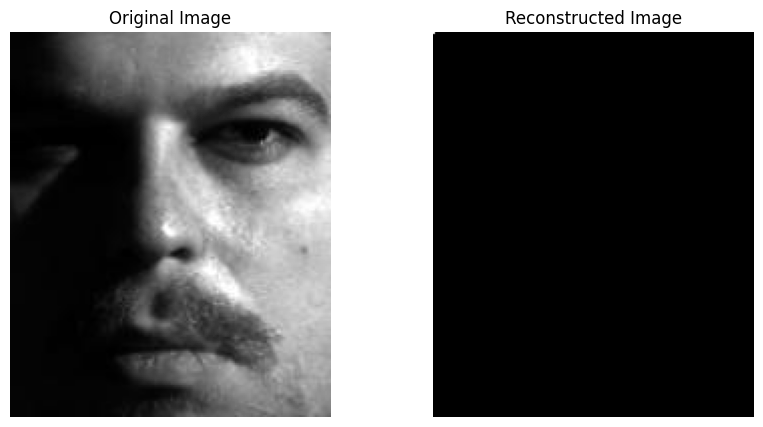

Epoch [2/20], Loss: 1.4457, SSIM: 0.9997
Validation SSIM: 0.9997


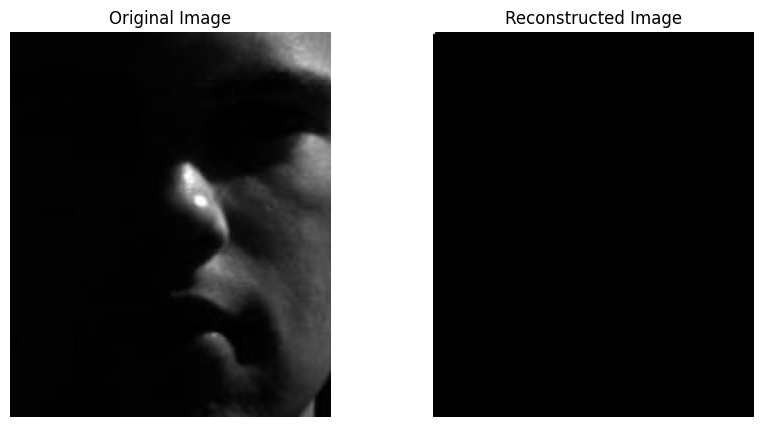

Epoch [3/20], Loss: 1.4454, SSIM: 0.9997
Validation SSIM: 0.9997


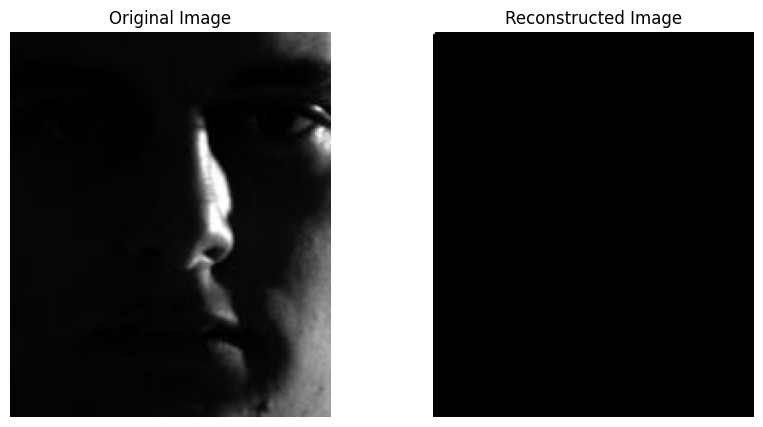

KeyboardInterrupt: 

In [ ]:
# Start training and validation loop
for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_loss = 0.0
    running_ssim = 0.0

    # Training loop
    for i, images in enumerate(train_loader):

        optimizer.zero_grad()  # Zero the gradients

        # Forward pass: encode and decode
        latents = encoder(images)
        reconstructed_images = decoder(latents)

        # Compute MSE loss
        loss = mse_loss(reconstructed_images, images)

        # Compute SSIM loss
        ssim_value = ssim_loss(reconstructed_images, images)
        loss += ssim_value  # You can adjust the weight of SSIM if needed

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate loss and SSIM values for averaging
        running_loss += loss.item()
        running_ssim += ssim_value

    # Average loss and SSIM for this epoch
    avg_loss = running_loss / len(train_loader)
    avg_ssim = running_ssim / len(train_loader)

    # Print training statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}")

    # Save the model checkpoint every few epochs
    if (epoch + 1) % 5 == 0:
        torch.save(encoder.state_dict(), f"encoder_epoch_{epoch+1}.pth")
        torch.save(decoder.state_dict(), f"decoder_epoch_{epoch+1}.pth")

    # Validation after each epoch (same as the training loop, but without gradients)
    encoder.eval()
    decoder.eval()

    running_ssim_val = 0.0
    with torch.no_grad():
        for images in test_loader:

            # Forward pass
            latents = encoder(images)
            reconstructed_images = decoder(latents)

            # Compute SSIM loss for validation
            ssim_value = ssim_loss(reconstructed_images, images)
            running_ssim_val += ssim_value

    # Average SSIM for validation set
    avg_ssim_val = running_ssim_val / len(test_loader)
    print(f"Validation SSIM: {avg_ssim_val:.4f}")

    random_idx = torch.randint(0, len(test_loader.dataset), (1,)).item()
    test_image = test_loader.dataset[random_idx].unsqueeze(0)
    encoder.eval()
    decoder.eval()

    # Pass the image through the encoder and decoder
    latents = encoder(test_image)
    reconstructed_image = decoder(latents)

    # Plot the original and reconstructed images
    plot_images(test_image, reconstructed_image)



In [ ]:
# torch.save(encoder.state_dict(), 'encoder_final.pth')
# torch.save(decoder.state_dict(), 'decoder_final.pth')